In [28]:
import torch
from components.datasets import load_dataset
from components.models import init_mf_params, create_anfis_model
from components.trainer import train_model
import numpy as np

# Config
config = {
    "dataset": "immunotherapy", # options: mackey-glass, circles, spiral, moons, swiss-roll, iris, digits
    "mf_type": "advanced", # options: simple, advanced
    "mf_init": "fcm", # options: fcm, random_uniform
    "K": 3,
    "s_mode": "alpha_beta",
    "n_epochs": 1000,
    "lr": 0.001,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}

# 1) Load dataset
X_train, X_test, y_train, y_test, task_type, n_outputs = load_dataset(config["dataset"])

# 2) Initialize MF
centers_init, spreads_init = init_mf_params(
    X_train, K=config["K"], method=config["mf_init"], scale=1.0, seed=config["seed"]
)

# 3) Create model
model = create_anfis_model(
    config["mf_type"], centers_init, spreads_init, n_outputs=n_outputs, s_mode=config["s_mode"]
).to(config["device"])



task_type: classification
n_outputs: 1
y unique: [0 1]
epoch    1 | train_loss=1.731073 | val_loss=4.236213, acc=0.7778
epoch  100 | train_loss=0.584793 | val_loss=1.912711, acc=0.8333
epoch  200 | train_loss=0.459213 | val_loss=1.346917, acc=0.7778
epoch  300 | train_loss=0.393256 | val_loss=1.202984, acc=0.8333
Early stopping at epoch 394 (best val_loss=1.183243)

Final Results:
Mode: alpha_beta
Train: accuracy rate 0.875 (63/72) | error 0.125 (9)
Test: accuracy rate 0.833 (15/18) | error 0.167 (3)

Per-rule, per-feature MF contributions and raw participation:
Rule 0, Feature 0: Raw weight -> Gaussian=0.5634, Sigmoid=0.4366
Rule 0, Feature 1: Raw weight -> Gaussian=0.3851, Sigmoid=0.6149
Rule 0, Feature 2: Raw weight -> Gaussian=0.3238, Sigmoid=0.6762
Rule 0, Feature 3: Raw weight -> Gaussian=0.3396, Sigmoid=0.6604
Rule 0, Feature 4: Raw weight -> Gaussian=0.2583, Sigmoid=0.7417
Rule 0, Feature 5: Raw weight -> Gaussian=0.6162, Sigmoid=0.3838
Rule 0, Feature 6: Raw weight -> Gaussian

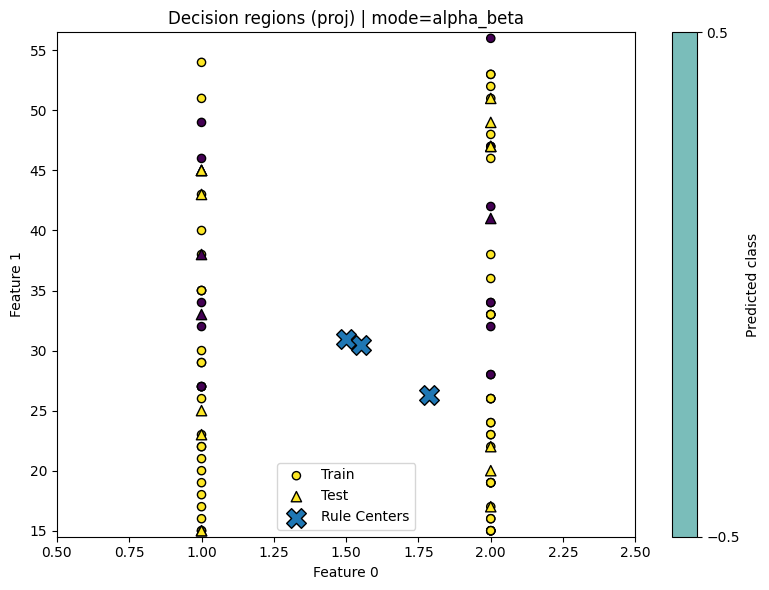

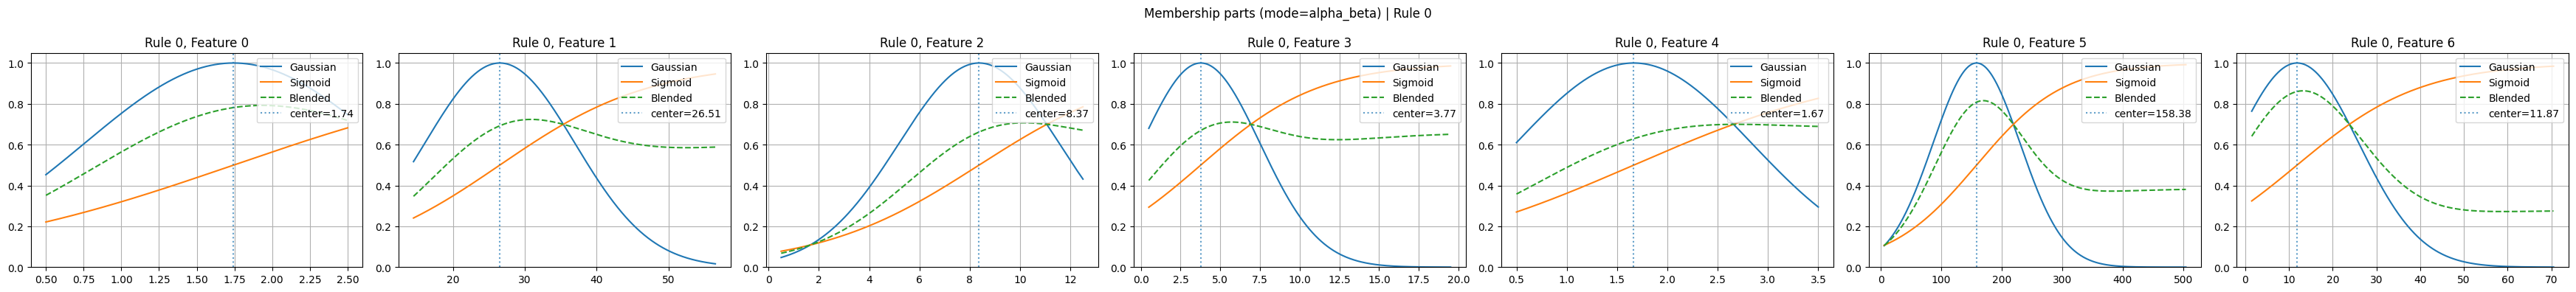

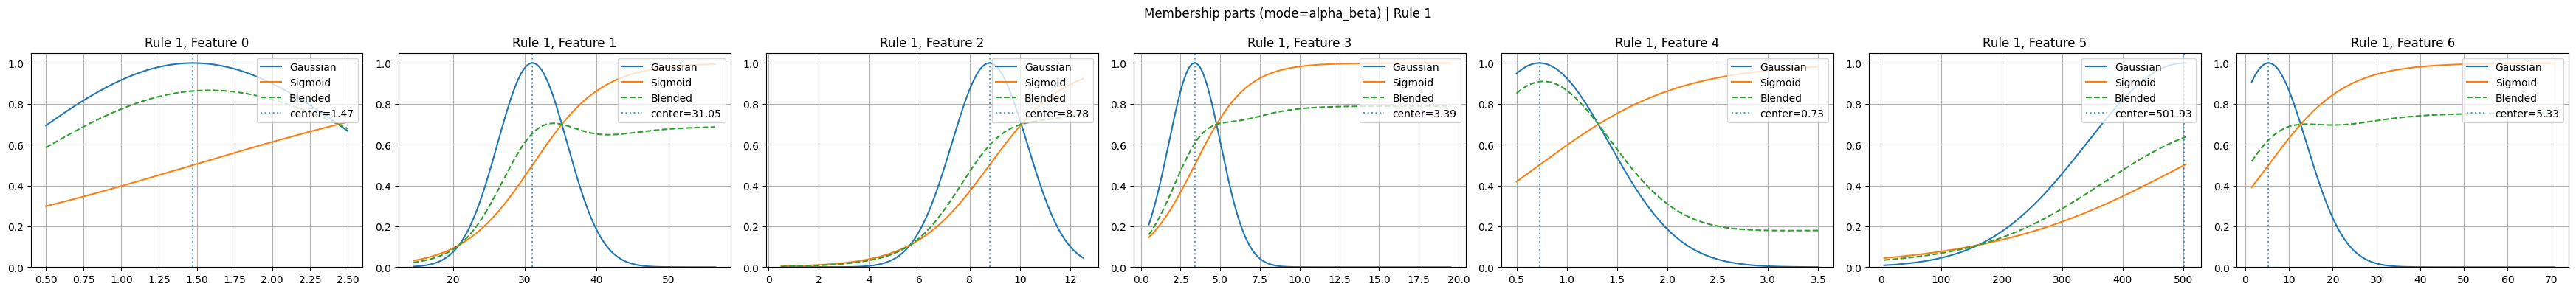

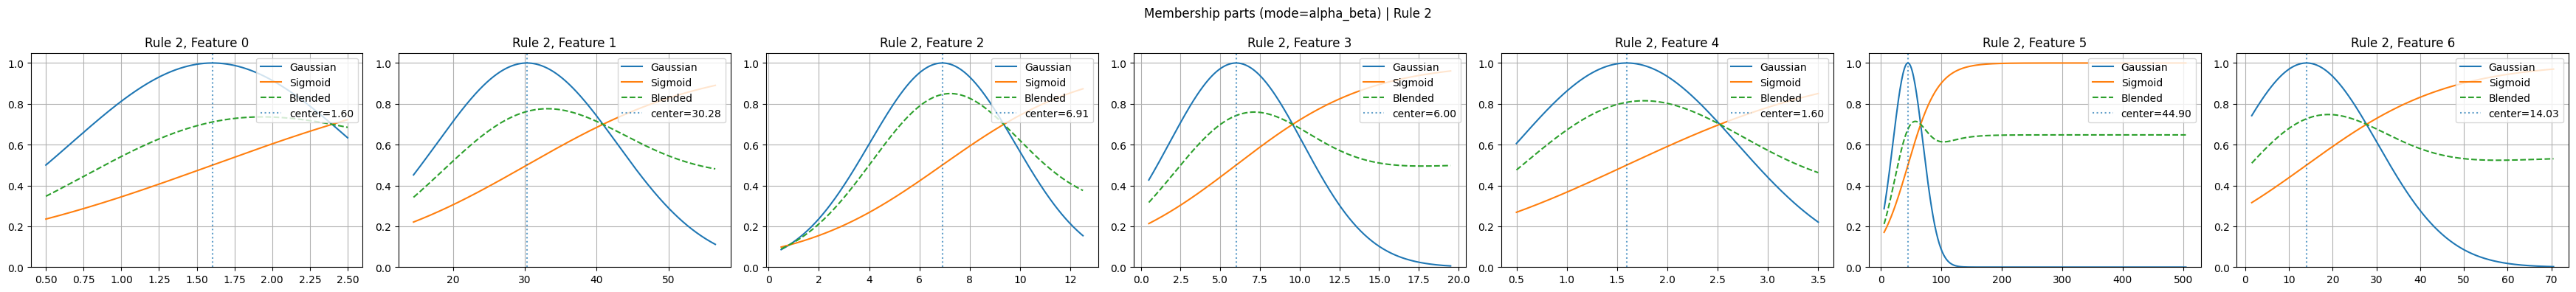

In [29]:
from components.utils import evaluate_anfis_model

print("task_type:", task_type)
print("n_outputs:", n_outputs)
print("y unique:", np.unique(y_train))


# 4) Train
model = train_model(
    model,
    X_train, y_train,
    X_test, y_test,
    task_type=task_type,
    n_outputs=n_outputs,
    n_epochs=config["n_epochs"],
    lr=config["lr"],
    device=config["device"],
)


# 5) Evaluate and plot results
evaluate_anfis_model(
    model, X_train, y_train, X_test, y_test, 
    device=config["device"], 
    s_mode_choice=config["s_mode"], 
    centers_init=centers_init,
    dataset_name=config["dataset"] 
)